In [1]:
# import
import os, sys, platform
import numpy as np
import pandas as pd
import scipy as sp
import seaborn as sns
from brainsmash.mapgen.base import Base
from scipy.spatial import distance
from tqdm import tqdm

# import plotting libraries
import matplotlib.pyplot as plt

In [2]:
# import functions from snaplab tools
os_name = platform.system()
print(f"Current OS is: {os_name}")

if os_name == "Linux":
    sys.path.extend([r'/home/lindenmp/research_projects/snaplab_tools'])
elif os_name == "Darwin":
    sys.path.extend([r'/Users/lindenmp/research_projects/snaplab_tools'])
from snaplab_tools.plotting.plotting import plot_correlation
from snaplab_tools.nulls.utils import get_null_p
from snaplab_tools.plotting.plotting import null_plot

Current OS is: Darwin


# Intro

In human neuroscience, we often use a range of *null models* to draw inferences from data. These nulls take many forms but are all fundamentally based on the idea of randomly shuffling (i.e., permuting) your data and then re-assessing your effect or parameter of interest using the permuted data.

For example, imagine you are interested in the correlation between variables `X` and `Y`. Let's say that when both `X` and `Y` are in their original unshuffled sate (i.e., `X_true`, `Y_true`), they yield some correlation coefficient, `corr(X_true, Y_true) = 0.50`. You can use a permutation test to see if that effect is *significantly lager than would occur by chance*.

You would do this by randomly shuffling one, *and only one*, of these variables thousands of times. Let's say you choose to randomly shuffle `X` 5,000 times. For each randomly shuffled version of `X`, `X_shuf`, you would recompute your correlation, `corr(X_shuf, Y_true) = 0.20`. Once you've done that 5,000 times for each instance of `X_shuf`, you will have a *null distribution containing 5,000 correlation coefficients*. By chance alone, some of the values in your null will yield substantially non-zero correlations. Then, the question becomes: **how many times do you observe correlations in your null that exceed the size of your true correlation?** The empirical answer to this question becomes your p-value. For example, if fewer than 5% of the values in your null distribution exceed the size of your true correlation, then the p-value of your permutation test is `p<0.05`. If fewer than 10%, then `p<0.1`. If fewer than 50%, then `p<0.5`. etc.

While conceptually straightforward, the above example *does not work in human neuroimaging*. This is because the data we use in our field has complex properties that means we cannot just naively shuffle the data and recompute outputs. For example, MRI data is characterized by smooth spatial variations; for example, a region with a certain cortical thickness will have neighoring regions that all have very similar levels of cortical thickness. This **autocorrelated** nature of our data means we cannot just randomly swap cortical thickness values around and recompute correlations to some other brain metric. Instead, we need to use nulls that *preserve* these complex features (e.g., autocorrelation) in our data when shuffling values.

Here, we will demonstrate a few null models that perform this preservation.

For a detailed discussion, check out [Váša & Mišić, 2022, Nature Reviews Neuroscience](https://www.nature.com/articles/s41583-022-00601-9).

# 1) Spatial autocorrelation-preserving null

The first null we will consider links directly to the above example. This null model generates a permuted version of a brain map while preserving the spatial autocorrelation (SA) of that brain map. There are many implementations of such a SA-preserving null, but we favor one called BrainSMASH. See [Burt et al., 2020, NeuroImage](https://www.sciencedirect.com/science/article/pii/S1053811920305243) and the authors [readthedocs](https://brainsmash.readthedocs.io/en/latest/) page for more details. Note, you should cite the Burt paper if you use BrainSMASH in your project!

## Load data

Let's load some data to use BrainSMASH

We will load a pair of vectors that encode some brain data. The first will be a vector of intracortical myelin content; this is extracted from the T1w/T2w ratio. The second will be a vector of intrinsic neural time scales; this is extracted by quantifying the decay of an autocorrelation function fit to regional resting-state fMRI time series. We're going to correlate these brain maps and use BrainSMASH to compute our p-value.

Note, this data is not provided with this tutorial. If you want to execute this notebook, you will need to provide your own data.

In [3]:
# directory where data is stored
if os_name == "Linux":
    in_dir = '/home/lindenmp/research_projects/nct_xr/data'
elif os_name == "Darwin":
    in_dir = '/Users/lindenmp/Google-Drive-Personal/work/data'

myelin_file = os.path.join(in_dir, 'hcp_schaefer400-7_myelin.npy')
myelin = np.mean(np.load(myelin_file), axis=1)
print(myelin.shape)

rsacf_file = os.path.join(in_dir, 'hcp_schaefer400-7_rsacf.npy')
rsacf = np.mean(np.load(rsacf_file)[:, 0, :], axis=1)
print(rsacf.shape)

(400,)
(400,)


We'll also load some data about parcellation. We'll need this to run BrainSMASH

In [4]:
# Load parcellation data
parc_file = os.path.join(in_dir, 'Schaefer2018_400Parcels_7Networks_order_FSLMNI152_1mm.Centroid_RAS.csv')
parc = pd.read_csv(parc_file, header=0, names=['ROI_Label', 'ROI_Name', 'R', 'A', 'S'], index_col=1)
parc.drop(columns=['ROI_Label'], inplace=True)
parc.head()

,R,A,S
ROI_Name,,,
7Networks_LH_Vis_1,-33,-42,-21
7Networks_LH_Vis_2,-30,-33,-18
7Networks_LH_Vis_3,-36,-62,-17
7Networks_LH_Vis_4,-24,-55,-8
7Networks_LH_Vis_5,-23,-73,-10


## Plot our true correlation

Now let's plot a basic correlation

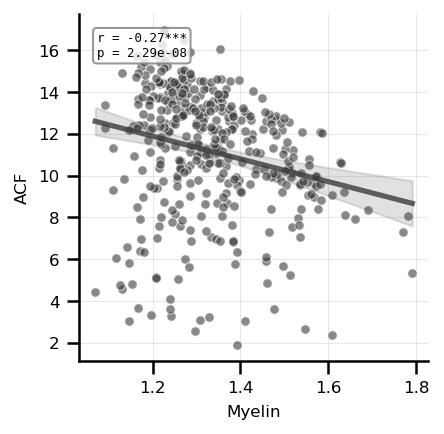

In [5]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(3, 3), dpi=150)
plot_correlation(myelin, rsacf, axes, x_label='Myelin', y_label='ACF', font_size=8,
                 method='spearman')
plt.show()

You can see that our true effect is `rho = -.27`. Now let's compute our null using BrainSMASH.

BrainSMASH, like many nulls we use, require that you input a distance matrix that describes the spatial relationship between brain regions (nodes). There are numerous ways to do this, some more sophisticated and accurate than others, but for this tutorial we'll take the simple approach of defining our distance matrix using the [X,Y,Z] spatial coordinates of the regions of our parcellation:

In [6]:
distance_matrix = distance.pdist(
    parc, "euclidean"
)  # get euclidean distances between nodes
distance_matrix = distance.squareform(distance_matrix)  # reshape to square matrix

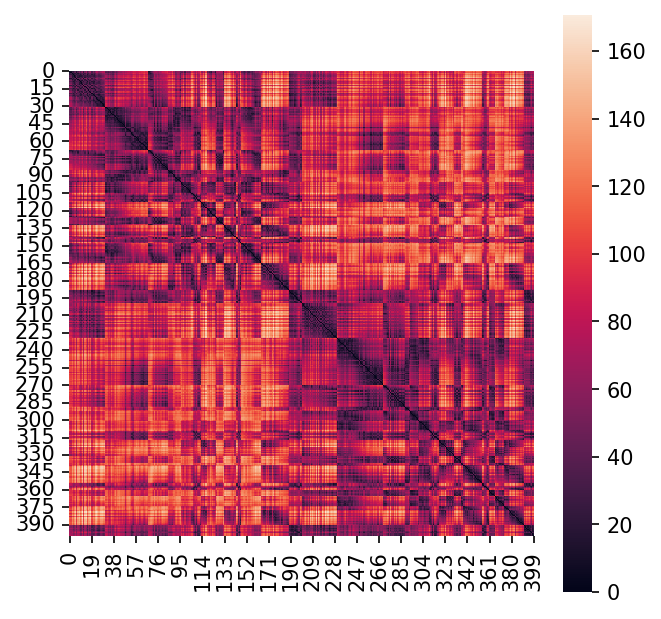

In [7]:
# plot distance matrix
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(5, 5), dpi=150)
sns.heatmap(distance_matrix, ax=axes, square=True)
plt.show()

You can see that the above matrix captures the fact that some regions are really close to each other in the brain (dark colors), while others are far apart (hot colors). BrainSMASH will use this information to preserve the spatial embedding of our brain regions when generate null brain maps.

Now let's run BrainSMASH on just one of our brain maps from above. We'll choose myelin:

In [8]:
n_perms = 5000
base = Base(x=myelin, D=distance_matrix)
myelin_null_maps = base(n=n_perms)
print(myelin_null_maps.shape)

(5000, 400)


As you can see, this produces 5,000 permuted versions of our myelin map, where the permutations are stored on the first axis. Thus, each row in `myelin_null_maps` correspondence to once instance of `X_shuf` from above.

Now we'll use these null myelin maps to compute a null distribution for our correlation with ACF:

In [9]:
null_distribution = np.zeros(n_perms)
for i in tqdm(np.arange(n_perms)):
    null_distribution[i] = sp.stats.spearmanr(myelin_null_maps[i], rsacf)[0]

100%|██████████| 5000/5000 [00:00<00:00, 7507.04it/s]


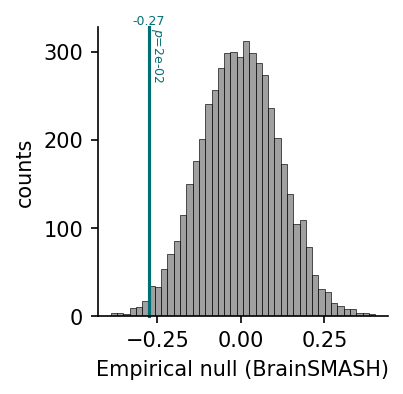

In [10]:
# primary score
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(2.5, 2.5), dpi=150)
observed = sp.stats.spearmanr(myelin, rsacf)[0]  # true correlation
p_val = get_null_p(observed, null_distribution, version='absolute')
null_plot(observed, null_distribution, 'Empirical null (BrainSMASH)', ax=axes, p_val=p_val)

The above shows that our true correlation `rho=-0.27` has a relatively large magnitude compared to our null distribution, which is centered around 0. Additionally, while there are some correlations in our null distribution that are larger than our observed effect, this occurs only rarely. As such, we end up with a small p-value of `2e-02`. This allows us to reject the null hypothesis that our true effect occurred by chance, when controlling for properties of the data preserved by BrainSMASH (i.e., spatial autocorrelation).

# 2) Null network models

Coming soon...